In [87]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [79]:
!pip install lightgbm

In [9]:
# Load the data
train = pd.read_csv (r"C:\Users\Serah\Downloads\climate-health-risk-prediction-challenge20260326-6977-l29abi\Train.csv")
test = pd.read_csv(r"C:\Users\Serah\Downloads\climate-health-risk-prediction-challenge20260326-6977-l29abi\Test.csv")
climate =pd.read_csv(r"C:\Users\Serah\Downloads\climate-health-risk-prediction-challenge20260326-6977-l29abi\climate_features.csv")
print("Train shape:", train.shape)
print ("Test shape:", test.shape)
print("Climate shape:", climate.shape)

Train shape: (3146, 13)
Test shape: (1030, 12)
Climate shape: (4176, 18)


In [15]:
# Checking the first 5 rows
train.head(5)

,ID,zone,gender,deathdate,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,location,is_climate_sensitive
0,ID_1FE951BD,Rural,Male,2007-10-02,30.0,21.137037,25.569017,18.451642,0.951601,0.584646,33.546344,"Izimba, Iganga, Uganda",1
1,ID_5927A443,Rural,Male,2008-01-05,2.0,24.062790,29.312026,18.977212,0.053352,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
2,ID_C4E67025,Rural,Female,2008-02-14,31.0,22.407868,26.746058,18.112977,0.090349,0.573420,33.483655,"Buluza, Iganga, Uganda",1
3,ID_44DC5CE9,Rural,Female,2008-02-15,1.0,23.315198,28.056889,18.955708,0.286814,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
4,ID_33C677BB,Rural,Female,2008-02-15,69.0,23.315198,28.056889,18.955708,0.286814,1.072343,34.226647,"Magada, Mbale City, Bugisa sub-region, Eastern...",0


In [17]:
# Check the target distribution
print(train['is_climate_sensitive'].value_counts())
print()
print(train['is_climate_sensitive'].value_counts(normalize=True).round(3))

is_climate_sensitive
1    2047
0    1099
Name: count, dtype: int64

is_climate_sensitive
1    0.651
0    0.349
Name: proportion, dtype: float64


In [23]:
# Check for missing values 
print("TRAIN missing values")
print(train.isnull().sum())

print("\nCLIMATE missing values")
print(climate.isnull().sum())

TRAIN missing values
ID                      0
zone                    0
gender                  0
deathdate               0
age                     0
avg_temperature         0
max_temperature         0
min_temperature         0
precipitation           0
latitude                0
longitude               0
location                0
is_climate_sensitive    0
dtype: int64

CLIMATE missing values
ID                     0
deathdate              0
elevation              0
hot_days_30d           0
max_daily_rain_30d     0
ndvi_30d               0
ndvi_90d               0
rain_days_30d          0
rain_sum_30d           0
rain_sum_7d            0
rain_sum_90d           0
slope                  0
tavg_30d               0
tavg_7d                0
tavg_90d               0
temp_range_mean_30d    0
tmax_30d               0
tmin_30d               0
dtype: int64


In [29]:
# Checking data types
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3146 entries, 0 to 3145
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3146 non-null   object 
 1   zone                  3146 non-null   object 
 2   gender                3146 non-null   object 
 3   deathdate             3146 non-null   object 
 4   age                   3146 non-null   float64
 5   avg_temperature       3146 non-null   float64
 6   max_temperature       3146 non-null   float64
 7   min_temperature       3146 non-null   float64
 8   precipitation         3146 non-null   float64
 9   latitude              3146 non-null   float64
 10  longitude             3146 non-null   float64
 11  location              3146 non-null   object 
 12  is_climate_sensitive  3146 non-null   int64  
dtypes: float64(7), int64(1), object(5)
memory usage: 319.6+ KB


In [33]:
# checking the statistics
train.describe()

,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,is_climate_sensitive
count,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000
mean,24.243484,22.066541,26.206879,18.514193,1.519907,0.630242,33.407442,0.650668
std,31.428833,1.095122,1.691347,0.891524,1.621088,0.172728,0.579933,0.476835
min,0.000000,18.852803,20.884623,15.018778,0.000000,0.089819,30.782817,0.000000
25%,0.000000,21.319885,25.260527,17.954814,0.286814,0.564758,33.473515,0.000000
50%,3.000000,21.931299,26.081829,18.510478,1.034344,0.591961,33.483544,1.000000
75%,49.000000,22.652860,27.015877,19.040655,2.222345,0.608396,33.519695,1.000000
max,110.000000,27.012223,34.080947,21.849602,16.606523,1.187892,34.226647,1.000000


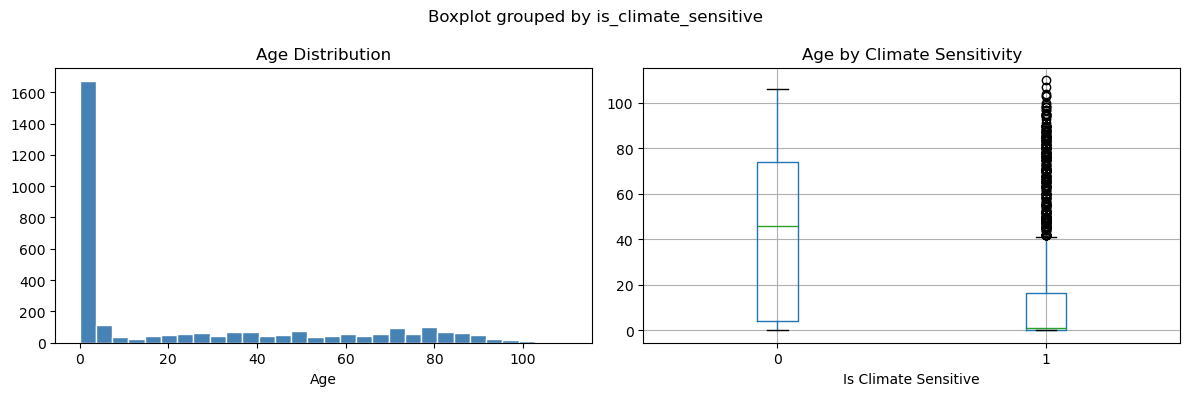

In [35]:
# Checking how age distribution relates to the target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(train['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# Age vs target
train.boxplot(column='age', by='is_climate_sensitive', ax=axes[1])
axes[1].set_title('Age by Climate Sensitivity')
axes[1].set_xlabel('Is Climate Sensitive')

plt.tight_layout()
plt.show()

In [51]:
def engineer_features(df):
    df = df.copy()
    
    # 1. Extract date features
    df['deathdate'] = pd.to_datetime(df['deathdate'])
    df['month'] = df['deathdate'].dt.month
    df['season'] = df['month'].map({
        12:0, 1:0, 2:0,
        3:1, 4:1, 5:1,
        6:2, 7:2, 8:2,
        9:3, 10:3, 11:3
    })
    df['year'] = df['deathdate'].dt.year
    df['day_of_year'] = df['deathdate'].dt.dayofyear
    
    # 2. Temperature features
    df['temp_range'] = df['max_temperature'] - df['min_temperature']
    df['temp_above_avg'] = df['avg_temperature'] - df['avg_temperature'].mean()
    
    # 3. Age groups
    df['age_group'] = pd.cut(df['age'],
                              bins=[-1, 1, 5, 15, 60, 200],
                              labels=['infant', 'child', 'teen', 'adult', 'elderly'])
    
    # 4. Rain flag
    df['is_rainy'] = (df['precipitation'] > 0).astype(int)
    
    # 5. Drop columns we don't need
    df = df.drop(columns=['deathdate', 'location', 'latitude', 'longitude'])
    
    return df

train_fe = engineer_features(train)
test_fe = engineer_features(test)

print("New shape:", train_fe.shape)
print("\nNew columns:", list(train_fe.columns))

New shape: (3146, 17)

New columns: ['ID', 'zone', 'gender', 'age', 'avg_temperature', 'max_temperature', 'min_temperature', 'precipitation', 'is_climate_sensitive', 'month', 'season', 'year', 'day_of_year', 'temp_range', 'temp_above_avg', 'age_group', 'is_rainy']


In [53]:
# Drop deathdate from climate features (we already extracted what we need)
climate_clean = climate.drop(columns=['deathdate'])

# Merge on ID
train_fe = train_fe.merge(climate_clean, on='ID', how='left')
test_fe = test_fe.merge(climate_clean, on='ID', how='left')

print("Train shape after merge:", train_fe.shape)
print("Test shape after merge:", test_fe.shape)

# Double check no new nulls crept in
print("\nAny nulls?", train_fe.isnull().sum().sum())

Train shape after merge: (3146, 33)
Test shape after merge: (1030, 32)

Any nulls? 0


In [57]:
# Building the baseline the model
# Define X and y
X = train_fe.drop(columns=['ID', 'is_climate_sensitive'])
y = train_fe['is_climate_sensitive']
X_test = test_fe.drop(columns=['ID'])


In [59]:
# Encode categorical columns
cat_cols = ['zone', 'gender', 'age_group']
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))
    X_test[col] = le.fit_transform(X_test[col].astype(str))

In [61]:
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (2516, 31)
X_val shape: (630, 31)


In [63]:
# Train a Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Evaluate
val_proba = model.predict_proba(X_val)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)

f1 = f1_score(y_val, val_pred)
auc = roc_auc_score(y_val, val_proba)
final_score = 0.60 * f1 + 0.40 * auc

print(f"F1 Score:     {f1:.4f}")
print(f"ROC-AUC:      {auc:.4f}")
print(f"Final Score:  {final_score:.4f}")
print()
print(classification_report(y_val, val_pred))

F1 Score:     0.7977
ROC-AUC:      0.7966
Final Score:  0.7973

              precision    recall  f1-score   support

           0       0.63      0.46      0.53       220
           1       0.75      0.86      0.80       410

    accuracy                           0.72       630
   macro avg       0.69      0.66      0.66       630
weighted avg       0.71      0.72      0.70       630



In [67]:
# XGBoost
# Calculate class imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"scale_pos_weight: {ratio:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio,   # handles class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Evaluate
val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
val_pred_xgb = (val_proba_xgb >= 0.5).astype(int)

f1_xgb = f1_score(y_val, val_pred_xgb)
auc_xgb = roc_auc_score(y_val, val_proba_xgb)
final_xgb = 0.60 * f1_xgb + 0.40 * auc_xgb

print(f"\nF1 Score:     {f1_xgb:.4f}")
print(f"ROC-AUC:      {auc_xgb:.4f}")
print(f"Final Score:  {final_xgb:.4f}")
print()
print(classification_report(y_val, val_pred_xgb))

scale_pos_weight: 0.54

F1 Score:     0.7761
ROC-AUC:      0.8007
Final Score:  0.7860

              precision    recall  f1-score   support

           0       0.58      0.63      0.61       220
           1       0.79      0.76      0.78       410

    accuracy                           0.71       630
   macro avg       0.69      0.69      0.69       630
weighted avg       0.72      0.71      0.72       630



Negatives: 879, Positives: 1637
Correct ratio (neg/pos): 0.54


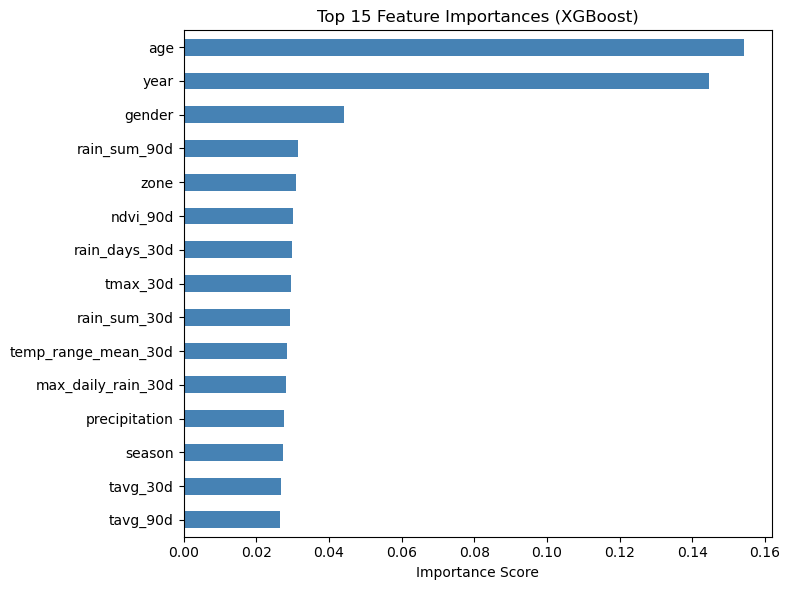

In [69]:
# Fix scale_pos_weight - it should be neg/pos not 0.54
print(f"Negatives: {neg}, Positives: {pos}")
print(f"Correct ratio (neg/pos): {neg/pos:.2f}")

# Plot feature importance
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [74]:
# Cross Validation to get more reliable score estimate
xgb_final = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(xgb_final, X, y, cv=cv, scoring='f1', n_jobs=-1)
auc_scores = cross_val_score(xgb_final, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("Cross-validation results (5 folds):")
print(f"F1 scores:   {f1_scores.round(4)}")
print(f"F1 mean:     {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
print()
print(f"AUC scores:  {auc_scores.round(4)}")
print(f"AUC mean:    {auc_scores.mean():.4f} (+/- {auc_scores.std():.4f})")
print()
print(f"Final Score: {(0.60 * f1_scores.mean() + 0.40 * auc_scores.mean()):.4f}")

Cross-validation results (5 folds):
F1 scores:   [0.8034 0.7868 0.7884 0.7556 0.7461]
F1 mean:     0.7761 (+/- 0.0216)

AUC scores:  [0.8127 0.8189 0.8136 0.781  0.776 ]
AUC mean:    0.8004 (+/- 0.0181)

Final Score: 0.7858


In [85]:
# The score is 0.7858 but can be pushed higher because the f1 is dragging it down 
# Trying LightGBM as it is faster and slightly better than XGBoost in this data
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

f1_lgbm = cross_val_score(lgbm_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
auc_lgbm = cross_val_score(lgbm_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("LightGBM Cross-validation results:")
print(f"F1 mean:     {f1_lgbm.mean():.4f} (+/- {f1_lgbm.std():.4f})")
print(f"AUC mean:    {auc_lgbm.mean():.4f} (+/- {auc_lgbm.std():.4f})")
print(f"Final Score: {(0.60 * f1_lgbm.mean() + 0.40 * auc_lgbm.mean()):.4f}")

print()
print("--- Comparison ---")
print(f"XGBoost:  {(0.60 * f1_scores.mean() + 0.40 * auc_scores.mean()):.4f}")
print(f"LightGBM: {(0.60 * f1_lgbm.mean() + 0.40 * auc_lgbm.mean()):.4f}")

LightGBM Cross-validation results:
F1 mean:     0.7762 (+/- 0.0170)
AUC mean:    0.7955 (+/- 0.0164)
Final Score: 0.7839

--- Comparison ---
XGBoost:  0.7858
LightGBM: 0.7839


In [89]:
# Tuning the XGBoost as it is better fit than the LightGBM
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500],
}

xgb_tune = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

grid_search = GridSearchCV(
    xgb_tune,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print("Best params:", grid_search.best_params_)
print("Best F1:", grid_search.best_score_.round(4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 500}
Best F1: 0.786


In [91]:
# Train best model on ALL training data
best_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=8,
    n_estimators=500,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

best_model.fit(X, y)
print("Model trained on full data!")

Model trained on full data!


In [93]:
# Generate predictions on test set
test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

# Create submission dataframe
submission = pd.DataFrame({
    'ID': test_fe['ID'],
    'TargetF1': test_pred,
    'TargetRAUC': test_proba
})

print(submission.head(10))
print("\nShape:", submission.shape)
print("TargetF1 distribution:")
print(submission['TargetF1'].value_counts())

            ID  TargetF1  TargetRAUC
0  ID_E760D84B         0    0.050389
1  ID_6EDEA907         1    0.971421
2  ID_B9FFC8D8         0    0.482147
3  ID_74C6C94E         0    0.257913
4  ID_0E02825D         1    0.923745
5  ID_DA1C6468         1    0.977028
6  ID_82EBD610         0    0.285570
7  ID_791C412A         1    0.994182
8  ID_8FB9365C         1    0.833430
9  ID_724491A7         0    0.449332

Shape: (1030, 3)
TargetF1 distribution:
TargetF1
1    670
0    360
Name: count, dtype: int64


In [101]:
submission.to_csv('climate_submission.csv', index=False)
print("Saved! ")

# Final check - make sure it looks right
check = pd.read_csv('climate_submission.csv')
print(check.head())
print("\nShape:", check.shape)
print("Any nulls?", check.isnull().sum().sum())

Saved! 
            ID  TargetF1  TargetRAUC
0  ID_E760D84B         0    0.050389
1  ID_6EDEA907         1    0.971421
2  ID_B9FFC8D8         0    0.482147
3  ID_74C6C94E         0    0.257913
4  ID_0E02825D         1    0.923745

Shape: (1030, 3)
Any nulls? 0


In [103]:
import os
print(os.getcwd())

C:\Users\Serah


In [105]:
from IPython.display import FileLink
FileLink('climate_submission.csv')

C:\Users\Serah\climate_submission.csv

In [107]:
def engineer_features_v2(df):
    df = df.copy()
    
    # 1. Date features
    df['deathdate'] = pd.to_datetime(df['deathdate'])
    df['month'] = df['deathdate'].dt.month
    df['season'] = df['month'].map({
        12:0, 1:0, 2:0,
        3:1, 4:1, 5:1,
        6:2, 7:2, 8:2,
        9:3, 10:3, 11:3
    })
    df['year'] = df['deathdate'].dt.year
    df['day_of_year'] = df['deathdate'].dt.dayofyear
    
    # 2. Temperature features
    df['temp_range'] = df['max_temperature'] - df['min_temperature']
    df['temp_above_avg'] = df['avg_temperature'] - df['avg_temperature'].mean()
    
    # 3. Age groups
    df['age_group'] = pd.cut(df['age'],
                              bins=[-1, 1, 5, 15, 60, 200],
                              labels=[0, 1, 2, 3, 4])
    df['age_group'] = df['age_group'].astype(int)
    
    # 4. Rain flag
    df['is_rainy'] = (df['precipitation'] > 0).astype(int)
    
    # 5. NEW: Interaction features
    df['age_x_precip'] = df['age'] * df['precipitation']
    df['age_x_season'] = df['age'] * df['season']
    df['age_x_temp'] = df['age'] * df['avg_temperature']
    df['young_rainy'] = ((df['age'] <= 5) & (df['precipitation'] > 0)).astype(int)
    
    # 6. NEW: Extract region from location
    df['region'] = df['location'].str.extract(r',\s*([^,]+),\s*Uganda')
    df['region'] = df['region'].fillna('Unknown')
    
    # 7. Drop columns
    df = df.drop(columns=['deathdate', 'location', 'latitude', 'longitude'])
    
    return df

train_v2 = engineer_features_v2(train)
test_v2 = engineer_features_v2(test)

# Merge climate features
train_v2 = train_v2.merge(climate_clean, on='ID', how='left')
test_v2 = test_v2.merge(climate_clean, on='ID', how='left')

print("New shape:", train_v2.shape)
print("Sample regions:", train_v2['region'].value_counts().head(5))

New shape: (3146, 38)
Sample regions: region
Iganga            1973
Eastern Region     524
Mayuge             268
Bugweri            199
Western Region     128
Name: count, dtype: int64


In [109]:
# Set up X and y with new features
X_v2 = train_v2.drop(columns=['ID', 'is_climate_sensitive'])
y_v2 = train_v2['is_climate_sensitive']
X_test_v2 = test_v2.drop(columns=['ID'])

# Encode categorical columns
cat_cols_v2 = ['zone', 'gender', 'region']
for col in cat_cols_v2:
    le = LabelEncoder()
    X_v2[col] = le.fit_transform(X_v2[col].astype(str))
    X_test_v2[col] = le.fit_transform(X_test_v2[col].astype(str))

print("X_v2 shape:", X_v2.shape)
print("Any nulls?", X_v2.isnull().sum().sum())

X_v2 shape: (3146, 36)
Any nulls? 0


In [111]:
xgb_v2 = XGBClassifier(
    learning_rate=0.1,
    max_depth=8,
    n_estimators=500,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

f1_v2 = cross_val_score(xgb_v2, X_v2, y_v2, cv=cv, scoring='f1', n_jobs=-1)
auc_v2 = cross_val_score(xgb_v2, X_v2, y_v2, cv=cv, scoring='roc_auc', n_jobs=-1)

print("V2 Cross-validation results:")
print(f"F1 mean:     {f1_v2.mean():.4f} (+/- {f1_v2.std():.4f})")
print(f"AUC mean:    {auc_v2.mean():.4f} (+/- {auc_v2.std():.4f})")
print(f"Final Score: {(0.60 * f1_v2.mean() + 0.40 * auc_v2.mean()):.4f}")
print()
print("--- Comparison ---")
print(f"V1 (original): {(0.60 * f1_scores.mean() + 0.40 * auc_scores.mean()):.4f}")
print(f"V2 (new feats): {(0.60 * f1_v2.mean() + 0.40 * auc_v2.mean()):.4f}")

V2 Cross-validation results:
F1 mean:     0.7808 (+/- 0.0120)
AUC mean:    0.7930 (+/- 0.0154)
Final Score: 0.7857

--- Comparison ---
V1 (original): 0.7858
V2 (new feats): 0.7857


In [115]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Train all three models on full data
xgb_ens = XGBClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=500,
    scale_pos_weight=ratio, random_state=42,
    eval_metric='logloss', verbosity=0
)

lgbm_ens = LGBMClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=500,
    class_weight='balanced', random_state=42, verbosity=-1
)

rf_ens = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=42, n_jobs=-1
)

# Cross-validate each
f1_xgb_e = cross_val_score(xgb_ens, X_v2, y_v2, cv=cv, scoring='f1', n_jobs=-1)
f1_lgbm_e = cross_val_score(lgbm_ens, X_v2, y_v2, cv=cv, scoring='f1', n_jobs=-1)
f1_rf_e = cross_val_score(rf_ens, X_v2, y_v2, cv=cv, scoring='f1', n_jobs=-1)

auc_xgb_e = cross_val_score(xgb_ens, X_v2, y_v2, cv=cv, scoring='roc_auc', n_jobs=-1)
auc_lgbm_e = cross_val_score(lgbm_ens, X_v2, y_v2, cv=cv, scoring='roc_auc', n_jobs=-1)
auc_rf_e = cross_val_score(rf_ens, X_v2, y_v2, cv=cv, scoring='roc_auc', n_jobs=-1)

print("Individual model scores:")
print(f"XGBoost:  F1={f1_xgb_e.mean():.4f}  AUC={auc_xgb_e.mean():.4f}  Score={0.6*f1_xgb_e.mean()+0.4*auc_xgb_e.mean():.4f}")
print(f"LightGBM: F1={f1_lgbm_e.mean():.4f}  AUC={auc_lgbm_e.mean():.4f}  Score={0.6*f1_lgbm_e.mean()+0.4*auc_lgbm_e.mean():.4f}")
print(f"RF:       F1={f1_rf_e.mean():.4f}  AUC={auc_rf_e.mean():.4f}  Score={0.6*f1_rf_e.mean()+0.4*auc_rf_e.mean():.4f}")

Individual model scores:
XGBoost:  F1=0.7808  AUC=0.7930  Score=0.7857
LightGBM: F1=0.7869  AUC=0.7888  Score=0.7877
RF:       F1=0.8005  AUC=0.8090  Score=0.8039


In [117]:
# Train all three on full data
xgb_ens.fit(X_v2, y_v2)
lgbm_ens.fit(X_v2, y_v2)
rf_ens.fit(X_v2, y_v2)

# Get probabilities from each model
xgb_proba = xgb_ens.predict_proba(X_test_v2)[:, 1]
lgbm_proba = lgbm_ens.predict_proba(X_test_v2)[:, 1]
rf_proba = rf_ens.predict_proba(X_test_v2)[:, 1]

# Average the probabilities (soft voting)
ensemble_proba = (xgb_proba + lgbm_proba + rf_proba) / 3
ensemble_pred = (ensemble_proba >= 0.5).astype(int)

# Save submission
submission_v2 = pd.DataFrame({
    'ID': test_v2['ID'],
    'TargetF1': ensemble_pred,
    'TargetRAUC': ensemble_proba
})

print(submission_v2.head(10))
print("\nShape:", submission_v2.shape)
print("TargetF1 distribution:")
print(submission_v2['TargetF1'].value_counts())

            ID  TargetF1  TargetRAUC
0  ID_E760D84B         0    0.201375
1  ID_6EDEA907         1    0.905534
2  ID_B9FFC8D8         0    0.483335
3  ID_74C6C94E         1    0.684861
4  ID_0E02825D         1    0.870343
5  ID_DA1C6468         1    0.879887
6  ID_82EBD610         0    0.307228
7  ID_791C412A         1    0.952989
8  ID_8FB9365C         1    0.846467
9  ID_724491A7         1    0.575388

Shape: (1030, 3)
TargetF1 distribution:
TargetF1
1    691
0    339
Name: count, dtype: int64


In [119]:
submission_v2.to_csv('submission_v2.csv', index=False)

from IPython.display import FileLink
FileLink('submission_v2.csv')

C:\Users\Serah\submission_v2.csv

In [121]:
def engineer_features_v3(df, fit_encoder=True, region_encoder=None):
    df = df.copy()
    
    # Date features
    df['deathdate'] = pd.to_datetime(df['deathdate'])
    df['month'] = df['deathdate'].dt.month
    df['season'] = df['month'].map({
        12:0, 1:0, 2:0,
        3:1, 4:1, 5:1,
        6:2, 7:2, 8:2,
        9:3, 10:3, 11:3
    })
    df['year'] = df['deathdate'].dt.year
    df['day_of_year'] = df['deathdate'].dt.dayofyear
    df['quarter'] = df['deathdate'].dt.quarter
    
    # Temperature features
    df['temp_range'] = df['max_temperature'] - df['min_temperature']
    df['temp_above_avg'] = df['avg_temperature'] - df['avg_temperature'].mean()
    df['heat_stress'] = df['max_temperature'] * df['precipitation']
    
    # Age features
    df['age_group'] = pd.cut(df['age'],
                              bins=[-1, 1, 5, 15, 60, 200],
                              labels=[0, 1, 2, 3, 4])
    df['age_group'] = df['age_group'].astype(int)
    df['is_infant'] = (df['age'] <= 1).astype(int)
    df['is_child'] = (df['age'] <= 5).astype(int)
    df['is_elderly'] = (df['age'] >= 60).astype(int)
    
    # Interaction features
    df['age_x_precip'] = df['age'] * df['precipitation']
    df['age_x_season'] = df['age'] * df['season']
    df['age_x_temp'] = df['age'] * df['avg_temperature']
    df['young_rainy'] = ((df['age'] <= 5) & (df['precipitation'] > 0)).astype(int)
    df['infant_hot'] = ((df['age'] <= 1) & (df['avg_temperature'] > 23)).astype(int)
    df['elderly_cold'] = ((df['age'] >= 60) & (df['min_temperature'] < 17)).astype(int)
    
    # Rain features
    df['is_rainy'] = (df['precipitation'] > 0).astype(int)
    df['heavy_rain'] = (df['precipitation'] > 5).astype(int)
    
    # Region extraction
    df['region'] = df['location'].str.extract(r',\s*([^,]+),\s*Uganda')
    df['region'] = df['region'].fillna('Unknown')
    
    # Drop columns
    df = df.drop(columns=['deathdate', 'location', 'latitude', 'longitude'])
    
    return df

train_v3 = engineer_features_v3(train)
test_v3 = engineer_features_v3(test)

# Merge climate features
train_v3 = train_v3.merge(climate_clean, on='ID', how='left')
test_v3 = test_v3.merge(climate_clean, on='ID', how='left')

print("Shape:", train_v3.shape)
print("New columns added successfully!")

Shape: (3146, 46)
New columns added successfully!


In [123]:
X_v3 = train_v3.drop(columns=['ID', 'is_climate_sensitive'])
y_v3 = train_v3['is_climate_sensitive']
X_test_v3 = test_v3.drop(columns=['ID'])

cat_cols_v3 = ['zone', 'gender', 'region']
for col in cat_cols_v3:
    le = LabelEncoder()
    X_v3[col] = le.fit_transform(X_v3[col].astype(str))
    X_test_v3[col] = le.fit_transform(X_test_v3[col].astype(str))

print("X_v3 shape:", X_v3.shape)
print("Any nulls?", X_v3.isnull().sum().sum())

X_v3 shape: (3146, 44)
Any nulls? 0


In [137]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)

f1_cat = cross_val_score(cat_model, X_v3, y_v3, cv=cv, scoring='f1', n_jobs=-1)
auc_cat = cross_val_score(cat_model, X_v3, y_v3, cv=cv, scoring='roc_auc', n_jobs=-1)

print("CatBoost CV results:")
print(f"F1 mean:     {f1_cat.mean():.4f} (+/- {f1_cat.std():.4f})")
print(f"AUC mean:    {auc_cat.mean():.4f} (+/- {auc_cat.std():.4f})")
print(f"Final Score: {(0.60 * f1_cat.mean() + 0.40 * auc_cat.mean()):.4f}")

CatBoost CV results:
F1 mean:     0.7859 (+/- 0.0173)
AUC mean:    0.8014 (+/- 0.0135)
Final Score: 0.7921


In [135]:
!pip install catboost

In [139]:
# Retrain all models on full v3 data
xgb_v3 = XGBClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=500,
    scale_pos_weight=ratio, random_state=42,
    eval_metric='logloss', verbosity=0
)

lgbm_v3 = LGBMClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=500,
    class_weight='balanced', random_state=42, verbosity=-1
)

rf_v3 = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    max_depth=20, random_state=42, n_jobs=-1
)

cat_v3 = CatBoostClassifier(
    iterations=500, learning_rate=0.05,
    depth=8, auto_class_weights='Balanced',
    random_seed=42, verbose=0
)

# Train all on full data
print("Training XGBoost...")
xgb_v3.fit(X_v3, y_v3)
print("Training LightGBM...")
lgbm_v3.fit(X_v3, y_v3)
print("Training Random Forest...")
rf_v3.fit(X_v3, y_v3)
print("Training CatBoost...")
cat_v3.fit(X_v3, y_v3)
print("All models trained!")

Training XGBoost...
Training LightGBM...
Training Random Forest...
Training CatBoost...
All models trained!


In [141]:
# Get probabilities
xgb_p = xgb_v3.predict_proba(X_test_v3)[:, 1]
lgbm_p = lgbm_v3.predict_proba(X_test_v3)[:, 1]
rf_p = rf_v3.predict_proba(X_test_v3)[:, 1]
cat_p = cat_v3.predict_proba(X_test_v3)[:, 1]

# Weighted average — give RF and CatBoost more weight since they scored higher
ensemble_p = (0.2 * xgb_p + 0.2 * lgbm_p + 0.3 * rf_p + 0.3 * cat_p)
ensemble_pred = (ensemble_p >= 0.5).astype(int)

submission_v3 = pd.DataFrame({
    'ID': test_v3['ID'],
    'TargetF1': ensemble_pred,
    'TargetRAUC': ensemble_p
})

submission_v3.to_csv('submission_v3.csv', index=False)

print(submission_v3.head())
print("\nShape:", submission_v3.shape)
print("TargetF1 distribution:")
print(submission_v3['TargetF1'].value_counts())

from IPython.display import FileLink
FileLink('submission_v3.csv')

            ID  TargetF1  TargetRAUC
0  ID_E760D84B         0    0.205941
1  ID_6EDEA907         1    0.775653
2  ID_B9FFC8D8         1    0.530349
3  ID_74C6C94E         1    0.535618
4  ID_0E02825D         1    0.806931

Shape: (1030, 3)
TargetF1 distribution:
TargetF1
1    669
0    361
Name: count, dtype: int64


C:\Users\Serah\submission_v3.csv

In [143]:
# Train RF on v3 features
rf_best = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_v3, y_v3)

# CV score first
f1_rf_best = cross_val_score(rf_best, X_v3, y_v3, cv=cv, scoring='f1', n_jobs=-1)
auc_rf_best = cross_val_score(rf_best, X_v3, y_v3, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"RF CV Score: {(0.6*f1_rf_best.mean() + 0.4*auc_rf_best.mean()):.4f}")

# Generate submission
rf_proba_best = rf_best.predict_proba(X_test_v3)[:, 1]
rf_pred_best = (rf_proba_best >= 0.5).astype(int)

submission_v4 = pd.DataFrame({
    'ID': test_v3['ID'],
    'TargetF1': rf_pred_best,
    'TargetRAUC': rf_proba_best
})

submission_v4.to_csv('submission_v4.csv', index=False)
print("\nTargetF1 distribution:")
print(submission_v4['TargetF1'].value_counts())

from IPython.display import FileLink
FileLink('submission_v4.csv')

RF CV Score: 0.8006

TargetF1 distribution:
TargetF1
1    679
0    351
Name: count, dtype: int64


C:\Users\Serah\submission_v4.csv

In [145]:
from sklearn.model_selection import KFold

def engineer_features_v4(df):
    df = df.copy()
    
    # Date features
    df['deathdate'] = pd.to_datetime(df['deathdate'])
    df['month'] = df['deathdate'].dt.month
    df['season'] = df['month'].map({
        12:0, 1:0, 2:0,
        3:1, 4:1, 5:1,
        6:2, 7:2, 8:2,
        9:3, 10:3, 11:3
    })
    df['year'] = df['deathdate'].dt.year
    df['day_of_year'] = df['deathdate'].dt.dayofyear
    
    # Temperature features
    df['temp_range'] = df['max_temperature'] - df['min_temperature']
    df['temp_above_avg'] = df['avg_temperature'] - df['avg_temperature'].mean()
    
    # Age features
    df['age_group'] = pd.cut(df['age'],
                              bins=[-1, 1, 5, 15, 60, 200],
                              labels=[0, 1, 2, 3, 4])
    df['age_group'] = df['age_group'].astype(int)
    df['is_infant'] = (df['age'] <= 1).astype(int)
    df['is_child'] = (df['age'] <= 5).astype(int)
    
    # Interaction features
    df['age_x_precip'] = df['age'] * df['precipitation']
    df['age_x_season'] = df['age'] * df['season']
    df['young_rainy'] = ((df['age'] <= 5) & (df['precipitation'] > 0)).astype(int)
    
    # Rain flag
    df['is_rainy'] = (df['precipitation'] > 0).astype(int)
    
    # Region extraction
    df['region'] = df['location'].str.extract(r',\s*([^,]+),\s*Uganda')
    df['region'] = df['region'].fillna('Unknown')
    
    # Drop columns
    df = df.drop(columns=['deathdate', 'location', 'latitude', 'longitude'])
    
    return df

train_v4 = engineer_features_v4(train)
test_v4 = engineer_features_v4(test)

# Merge climate features
train_v4 = train_v4.merge(climate_clean, on='ID', how='left')
test_v4 = test_v4.merge(climate_clean, on='ID', how='left')

print("Shape:", train_v4.shape)

Shape: (3146, 39)


In [147]:
# Target encode region using cross-val to avoid leakage
global_mean = train_v4['is_climate_sensitive'].mean()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_v4['region_encoded'] = 0.0

for train_idx, val_idx in kf.split(train_v4):
    fold_train = train_v4.iloc[train_idx]
    region_map = fold_train.groupby('region')['is_climate_sensitive'].mean()
    train_v4.iloc[val_idx, train_v4.columns.get_loc('region_encoded')] = \
        train_v4.iloc[val_idx]['region'].map(region_map).fillna(global_mean)

# For test set use full training data
region_map_full = train_v4.groupby('region')['is_climate_sensitive'].mean()
test_v4['region_encoded'] = test_v4['region'].map(region_map_full).fillna(global_mean)

print("Region encoding sample:")
print(train_v4.groupby('region')['region_encoded'].mean().sort_values(ascending=False).head(8))

Region encoding sample:
region
Entebbe City      0.705551
Mayuge            0.657394
Iganga            0.653328
Western Region    0.641191
Eastern Region    0.639070
Bugweri           0.637452
Name: region_encoded, dtype: float64


In [149]:
X_v4 = train_v4.drop(columns=['ID', 'is_climate_sensitive', 'region'])
y_v4 = train_v4['is_climate_sensitive']
X_test_v4 = test_v4.drop(columns=['ID', 'region'])

cat_cols_v4 = ['zone', 'gender']
for col in cat_cols_v4:
    le = LabelEncoder()
    X_v4[col] = le.fit_transform(X_v4[col].astype(str))
    X_test_v4[col] = le.fit_transform(X_test_v4[col].astype(str))

print("X_v4 shape:", X_v4.shape)
print("Any nulls?", X_v4.isnull().sum().sum())

X_v4 shape: (3146, 37)
Any nulls? 0


In [151]:
xgb_v4 = XGBClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=500,
    scale_pos_weight=ratio, random_state=42,
    eval_metric='logloss', verbosity=0
)

lgbm_v4 = LGBMClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=500,
    class_weight='balanced', random_state=42, verbosity=-1
)

rf_v4 = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=42, n_jobs=-1
)

f1_xgb4 = cross_val_score(xgb_v4, X_v4, y_v4, cv=cv, scoring='f1', n_jobs=-1)
f1_lgbm4 = cross_val_score(lgbm_v4, X_v4, y_v4, cv=cv, scoring='f1', n_jobs=-1)
f1_rf4 = cross_val_score(rf_v4, X_v4, y_v4, cv=cv, scoring='f1', n_jobs=-1)

auc_xgb4 = cross_val_score(xgb_v4, X_v4, y_v4, cv=cv, scoring='roc_auc', n_jobs=-1)
auc_lgbm4 = cross_val_score(lgbm_v4, X_v4, y_v4, cv=cv, scoring='roc_auc', n_jobs=-1)
auc_rf4 = cross_val_score(rf_v4, X_v4, y_v4, cv=cv, scoring='roc_auc', n_jobs=-1)

print("Individual scores:")
print(f"XGBoost:  {(0.6*f1_xgb4.mean() + 0.4*auc_xgb4.mean()):.4f}")
print(f"LightGBM: {(0.6*f1_lgbm4.mean() + 0.4*auc_lgbm4.mean()):.4f}")
print(f"RF:       {(0.6*f1_rf4.mean() + 0.4*auc_rf4.mean()):.4f}")

Individual scores:
XGBoost:  0.7914
LightGBM: 0.7874
RF:       0.8013


In [154]:
# Train all on full data
print("Training XGBoost..."); xgb_v4.fit(X_v4, y_v4)
print("Training LightGBM..."); lgbm_v4.fit(X_v4, y_v4)
print("Training RF..."); rf_v4.fit(X_v4, y_v4)
print("All done!")

# Equal weight ensemble
xgb_p4 = xgb_v4.predict_proba(X_test_v4)[:, 1]
lgbm_p4 = lgbm_v4.predict_proba(X_test_v4)[:, 1]
rf_p4 = rf_v4.predict_proba(X_test_v4)[:, 1]

ensemble_p4 = (xgb_p4 + lgbm_p4 + rf_p4) / 3
ensemble_pred4 = (ensemble_p4 >= 0.5).astype(int)

submission_v5 = pd.DataFrame({
    'ID': test_v4['ID'],
    'TargetF1': ensemble_pred4,
    'TargetRAUC': ensemble_p4
})

submission_v5.to_csv('submission_v5.csv', index=False)
print("\nShape:", submission_v5.shape)
print("TargetF1 distribution:")
print(submission_v5['TargetF1'].value_counts())

from IPython.display import FileLink
FileLink('submission_v5.csv')

Training XGBoost...
Training LightGBM...
Training RF...
All done!

Shape: (1030, 3)
TargetF1 distribution:
TargetF1
1    690
0    340
Name: count, dtype: int64


C:\Users\Serah\submission_v5.csv